# Hopfield Networks

## Table of Contents

1. [Introduction & Mathematical Foundations](#1)
2. [Setup & Imports](#2)
3. [Storing Patterns — Hebbian Learning](#3)
4. [Pattern Recall from Noisy Input](#4)
5. [Energy Function & Trajectory Analysis](#5)
6. [Weight Matrix Visualisation](#6)
7. [Overlap Dynamics](#7)
8. [Synchronous vs Asynchronous Dynamics](#8)
9. [Storage Capacity Experiment](#9)
10. [Hebbian vs Storkey Learning](#10)
11. [Basin of Attraction Analysis](#11)
12. [Spurious States](#12)
13. [Application: Letter Pattern Recall](#13)

<a id="1"></a>
## 1. Mathematical Foundations

A Hopfield Network (Hopfield, 1982) is a fully connected recurrent neural network that serves as a content-addressable (associative) memory.

### Notation & Variable Types

| Symbol | Type | Description |
|---|---|---|
| $N$ | scalar $\in \mathbb{N}$ | Number of neurons in the network |
| $P$ | scalar $\in \mathbb{N}$ | Number of stored patterns |
| $s_i$ | scalar $\in \{-1,+1\}$ | State of neuron $i$ |
| $\mathbf{s} = (s_1, \dots, s_N)^T$ | vector $\in \{-1,+1\}^N$ | Full network state |
| $\boldsymbol{\xi}^\mu = (\xi_1^\mu, \dots, \xi_N^\mu)^T$ | vector $\in \{-1,+1\}^N$ | Stored pattern $\mu$ ($\mu = 1,\dots,P$) |
| $W = [w_{ij}]$ | matrix $\in \mathbb{R}^{N \times N}$ | Symmetric weight matrix ($w_{ij} = w_{ji}$, $w_{ii}=0$) |
| $w_{ij}$ | scalar $\in \mathbb{R}$ | Connection weight between neurons $i$ and $j$ |
| $h_i = \sum_j w_{ij} s_j$ | scalar $\in \mathbb{R}$ | Local field (net input) at neuron $i$ |
| $E(\mathbf{s})$ | scalar $\in \mathbb{R}$ | Energy of state $\mathbf{s}$ |
| $m^\mu$ | scalar $\in [-1, 1]$ | Overlap between $\mathbf{s}$ and pattern $\boldsymbol{\xi}^\mu$ |

### Hebbian Learning Rule

Given $P$ pattern vectors $\{\boldsymbol{\xi}^\mu\}_{\mu=1}^{P}$, each entry of the weight matrix $W$ is set by:

$$w_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} \xi_i^\mu \, \xi_j^\mu, \qquad w_{ii} = 0$$

In matrix form (outer product of pattern vectors):

$$W = \frac{1}{N} \sum_{\mu=1}^{P} \boldsymbol{\xi}^\mu (\boldsymbol{\xi}^\mu)^T, \quad \text{diag}(W) = 0$$

### Update Dynamics

Asynchronous — pick one neuron index $i$ (scalar), compute its local field $h_i$ (scalar), update:
$$s_i(t+1) = \operatorname{sgn}(h_i) = \operatorname{sgn}\!\left(\sum_{j=1}^{N} w_{ij}\, s_j(t)\right)$$

Synchronous — update the full state vector in one step:
$$\mathbf{s}(t+1) = \operatorname{sgn}\!\left(W\, \mathbf{s}(t)\right) \quad \in \{-1,+1\}^N$$

### Energy Function (Lyapunov Function)

The network has a scalar energy function that decreases under asynchronous updates:

$$E(\mathbf{s}) = -\frac{1}{2} \sum_{i \neq j} w_{ij}\, s_i\, s_j = -\frac{1}{2}\, \mathbf{s}^T W\, \mathbf{s} \quad \in \mathbb{R}$$

Theorem: $\Delta E \leq 0$ at every asynchronous step → dynamics converge to a local minimum (attractor).

### Storage Capacity

The maximum number of patterns (scalar) that can be reliably stored:

$$P_{\max} \approx \frac{N}{2 \ln N} \quad \text{(exact recall)}, \qquad P_c \approx 0.138\, N \quad \text{(non-zero overlap)}$$

<a id="2"></a>
## 2. Setup & Imports

In [1]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from hopfield.network import HopfieldNetwork
from hopfield.energy import EnergyAnalyzer
from hopfield.visualization import HopfieldVisualizer
from hopfield.utils import (
    generate_random_patterns,
    add_noise,
    hamming_distance,
    overlap,
    pattern_to_grid,
    make_letter_patterns,
    make_shape_patterns,
)

%matplotlib inline

# Publication-quality plot style
plt.rcParams.update({
    "figure.dpi"          : 150,
    "savefig.dpi"         : 300,
    "font.family"         : "serif",
    "font.serif"          : ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size"           : 10,
    "axes.titlesize"      : 11,
    "axes.labelsize"      : 10,
    "xtick.labelsize"     : 9,
    "ytick.labelsize"     : 9,
    "legend.fontsize"     : 9,
    "legend.framealpha"   : 0.8,
    "legend.edgecolor"    : "0.6",
    "axes.linewidth"      : 0.6,
    "axes.grid"           : False,
    "grid.linewidth"      : 0.4,
    "grid.alpha"          : 0.3,
    "lines.linewidth"     : 1.2,
    "lines.markersize"    : 4,
    "xtick.major.width"   : 0.5,
    "ytick.major.width"   : 0.5,
    "xtick.minor.width"   : 0.3,
    "ytick.minor.width"   : 0.3,
    "xtick.direction"     : "in",
    "ytick.direction"     : "in",
    "xtick.major.pad"     : 4,
    "ytick.major.pad"     : 4,
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
    "figure.constrained_layout.use" : True,
    "mathtext.fontset"    : "cm",
})

# Reproducibility
np.random.seed(42)

print("All modules loaded successfully!")
print(f"NumPy {np.__version__}")

All modules loaded successfully!
NumPy 2.2.6


In [2]:
# ── User Configuration ──────────────────────────────────────
# Adjust these parameters to explore different network behaviours.

# Main network
N          = 100                 # number of neurons
GRID_SHAPE = (10, 10)            # display grid (product must equal N)
P          = 6                   # number of patterns to store
SEED       = 42

# Recall demos (§4)
TARGET_PATTERN = 0               # index of the pattern to corrupt
NOISE_LEVELS_DEMO = [0.10, 0.20, 0.30, 0.50]

# Default noise for single-probe experiments (§5, §7, §8)
DEFAULT_NOISE = 0.25

# Capacity experiment (§9)
# NOTE: noise=0 tests fixed-point stability, matching the theoretical P_c definition
N_CAP        = 200
P_RANGE_CAP  = list(range(1, 50))
N_TRIALS_CAP = 15
NOISE_CAP    = 0.1

# Learning-rule comparison (§10)
N_COMP        = 200
P_RANGE_COMP  = list(range(1, 80))
N_TRIALS_COMP = 10
NOISE_COMP    = 0.1

# Basin / spurious analysis (§11–12)
N_PROBES_BASIN    = 2000
N_PROBES_SPURIOUS = 1000

# Letter recall (§13)
LETTER_NAMES = ["H", "A", "X", "T"]
LETTER_NOISE = 0.10

# Convergence analysis (§14)
N_CONV           = 100
NOISE_RANGE_CONV = np.arange(0.05, 0.55, 0.05)
P_LIST_CONV      = [2, 5, 8, 10, 12, 15]
N_TRIALS_CONV    = 20

MAX_STEPS = 100  # global default max recall steps

assert np.prod(GRID_SHAPE) == N, f"GRID_SHAPE {GRID_SHAPE} does not match N={N}"
print(f"Configuration: N={N}, P={P}, grid={GRID_SHAPE}")

Configuration: N=100, P=6, grid=(10, 10)


<a id="3"></a>
## 3. Storing Patterns — Hebbian Learning

We generate $P$ random bipolar pattern vectors $\boldsymbol{\xi}^\mu \in \{-1,+1\}^N$ and store them in the weight matrix $W \in \mathbb{R}^{N\times N}$ via the Hebbian rule:

$$W = \frac{1}{N} \sum_{\mu=1}^{P} \boldsymbol{\xi}^\mu (\boldsymbol{\xi}^\mu)^T, \quad w_{ii} = 0$$

Each stored pattern vector becomes a fixed point (attractor) of the dynamics — a state where the energy scalar $E(\boldsymbol{\xi}^\mu)$ is a local minimum.

HopfieldNetwork(n_neurons=100, stored_patterns=6, capacity~10.9)

Stored 6 patterns of dimension 100
Theoretical capacity: P_max ≈ 10.9


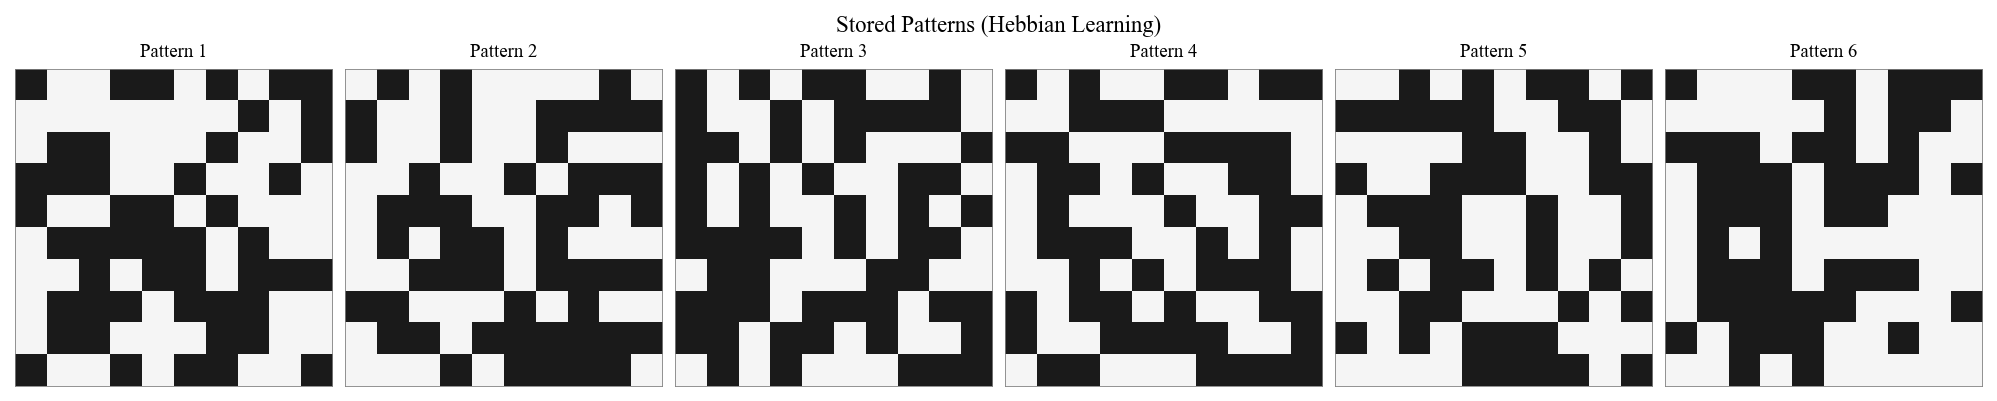

In [3]:
patterns = generate_random_patterns(P, N, seed=SEED)

net = HopfieldNetwork(n_neurons=N)
net.train(patterns)

print(net)
print(f"\nStored {P} patterns of dimension {N}")
print(f"Theoretical capacity: P_max ≈ {net.theoretical_capacity:.1f}")

viz = HopfieldVisualizer(net, grid_shape=GRID_SHAPE)
fig = viz.show_patterns(
    patterns,
    titles=[f"Pattern {i+1}" for i in range(P)],
    suptitle="Stored Patterns (Hebbian Learning)",
)
plt.show()

<a id="4"></a>
## 4. Pattern Recall from Noisy Input

Given a corrupted probe vector $\tilde{\mathbf{s}} \in \{-1,+1\}^N$ (obtained by flipping a fraction $\eta$ (scalar, $0 \leq \eta \leq 1$) of the bits of a stored pattern), the network iteratively updates each neuron's scalar state:

$$s_i(t+1) = \operatorname{sgn}\!\left(\sum_{j=1}^{N} w_{ij}\, s_j(t)\right) \quad \in \{-1,+1\}$$

until the full state vector $\mathbf{s}(t)$ converges to a fixed point.

The overlap (scalar) between the evolving state and a target pattern measures recall quality:

$$m^\mu(t) = \frac{1}{N} \sum_{i=1}^{N} s_i(t)\, \xi_i^\mu = \frac{1}{N}\, \mathbf{s}(t) \cdot \boldsymbol{\xi}^\mu \quad \in [-1, 1]$$

- $m^\mu = 1$: perfect match (state vector = pattern vector)
- $m^\mu = -1$: perfect negative (state vector = $-$pattern vector)
- $m^\mu \approx 0$: uncorrelated

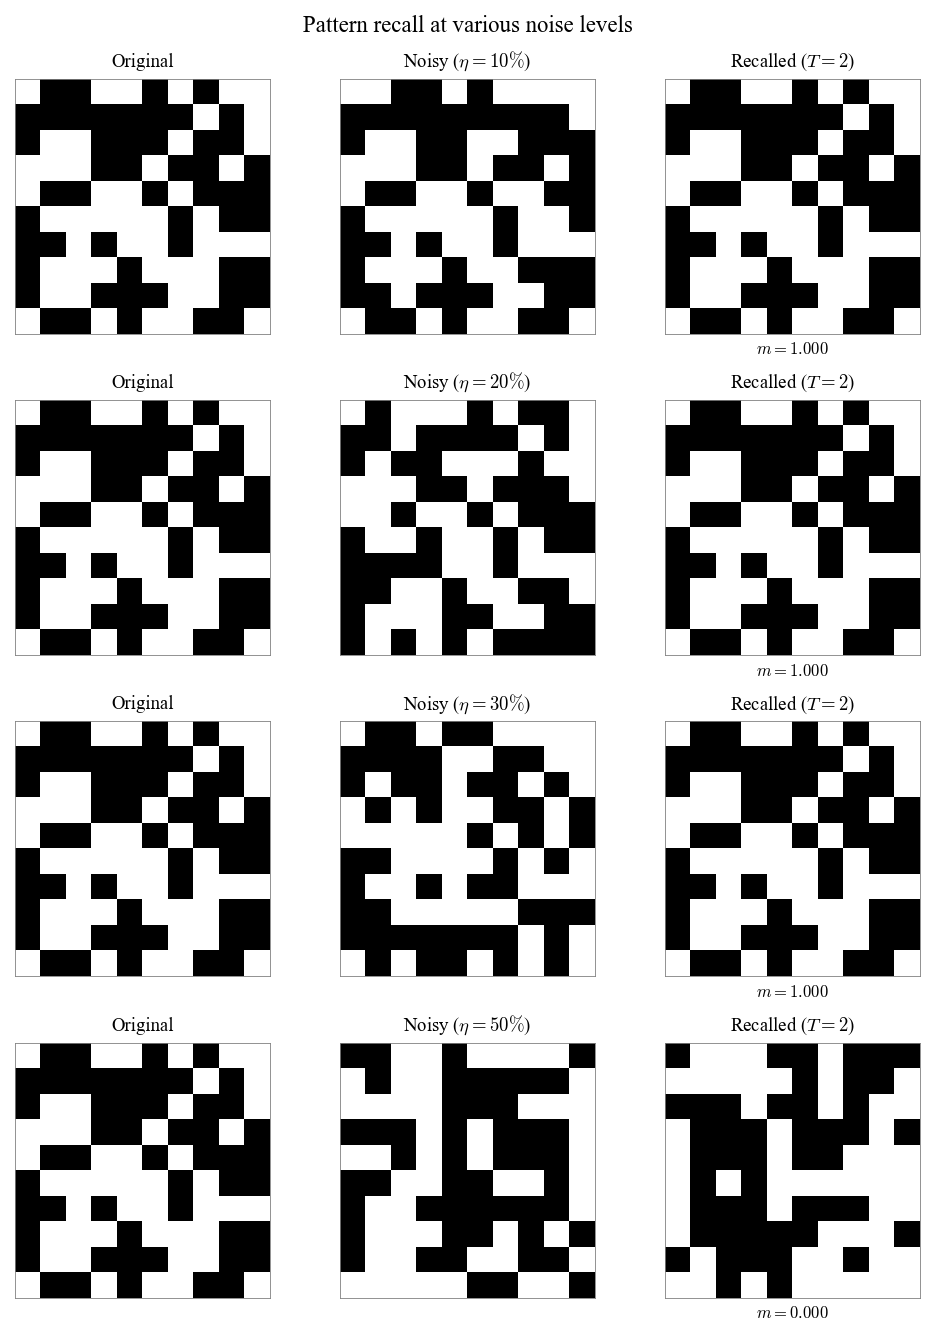

In [4]:
original = patterns[TARGET_PATTERN]

fig, axes = plt.subplots(len(NOISE_LEVELS_DEMO), 3, figsize=(6.5, 2.2 * len(NOISE_LEVELS_DEMO)))

for row, eta in enumerate(NOISE_LEVELS_DEMO):
    noisy = add_noise(original, noise_level=eta, rng=np.random.default_rng(row))
    recalled, info = net.recall(noisy, mode="async", max_steps=MAX_STEPS, record_history=True)

    for col, (data, title) in enumerate(zip(
        [original, noisy, recalled],
        ["Original", rf"Noisy ($\eta={eta*100:.0f}\%$)", f"Recalled ($T={info['steps']}$)"]
    )):
        ax = axes[row, col]
        ax.imshow(data.reshape(GRID_SHAPE), cmap="gray_r", interpolation="nearest", vmin=-1, vmax=1)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.4); spine.set_color("0.5")

    m = overlap(recalled, original)
    axes[row, 2].set_xlabel(f"$m = {m:.3f}$", fontsize=8)

fig.suptitle("Pattern recall at various noise levels", fontsize=11)
plt.show()

<a id="5"></a>
## 5. Energy Function & Trajectory Analysis

The energy $E$ is a scalar function of the state vector $\mathbf{s} \in \{-1,+1\}^N$ and the weight matrix $W \in \mathbb{R}^{N \times N}$:

$$E(\mathbf{s}) = -\frac{1}{2}\, \mathbf{s}^T W\, \mathbf{s} \quad \in \mathbb{R}$$

It acts as a Lyapunov function: guaranteed to decrease under asynchronous updates.

Proof sketch: When neuron $i$ flips from $s_i$ to $s_i'$ (both scalars $\in \{-1,+1\}$), the energy change (scalar) is:

$$\Delta E = -(s_i' - s_i) \underbrace{\sum_{j=1}^{N} w_{ij}\, s_j}_{h_i \;\text{(scalar: local field)}}$$

Since the update rule sets $s_i' = \operatorname{sgn}(h_i)$, we have $(s_i' - s_i) \cdot h_i \geq 0$, hence $\Delta E \leq 0$. ∎

Each stored pattern vector $\boldsymbol{\xi}^\mu$ sits at a local minimum of the scalar energy landscape.

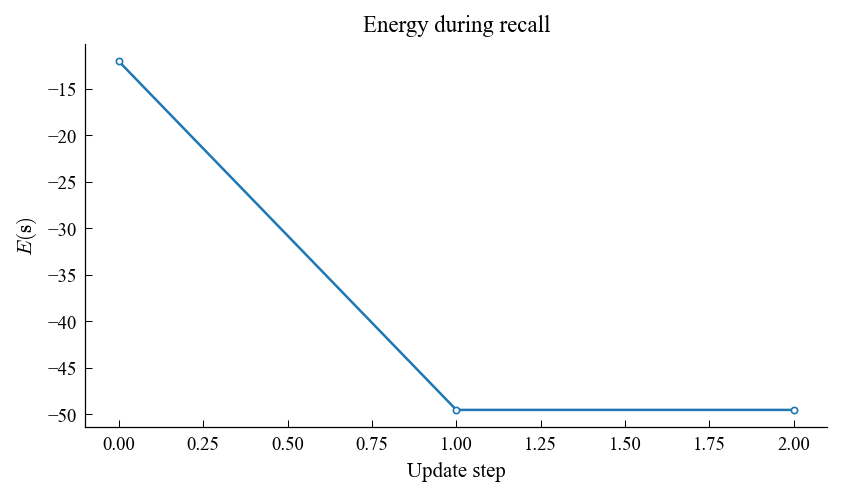

Converged : True | Steps: 2
Energy    : -12.04 → -49.52

Stored pattern energies : [-49.52 -48.28 -51.92 -51.2  -49.88 -47.52]
Final state energy        :      -49.52


In [5]:
noisy_probe = add_noise(patterns[0], noise_level=DEFAULT_NOISE, rng=np.random.default_rng(99))
recalled, info = net.recall(noisy_probe, mode="async", max_steps=MAX_STEPS, record_history=True)

analyzer = EnergyAnalyzer(net)

fig = viz.plot_energy_trajectory(info["energy_history"])
plt.show()

print(f"Converged : {info['converged']} | Steps: {info['steps']}")
print(f"Energy    : {info['energy_history'][0]:.2f} → {info['energy_history'][-1]:.2f}")

pattern_energies = analyzer.stored_pattern_energies()
print(f"\nStored pattern energies : {pattern_energies}")
print(f"Final state energy        :      {net.energy(recalled):.2f}")

<a id="6"></a>
## 6. Weight Matrix Visualisation

The weight matrix $W \in \mathbb{R}^{N \times N}$ encodes the memory of the network. Its properties:

- Symmetric: $w_{ij} = w_{ji}$ (each scalar entry equals its transpose)
- Zero diagonal: $w_{ii} = 0$ (no self-connections)

For uncorrelated random pattern vectors, the off-diagonal scalar entries scale as $w_{ij} \sim \mathcal{O}(P/N)$, while the Frobenius norm (scalar) of $W$ grows with the number of stored patterns $P$.

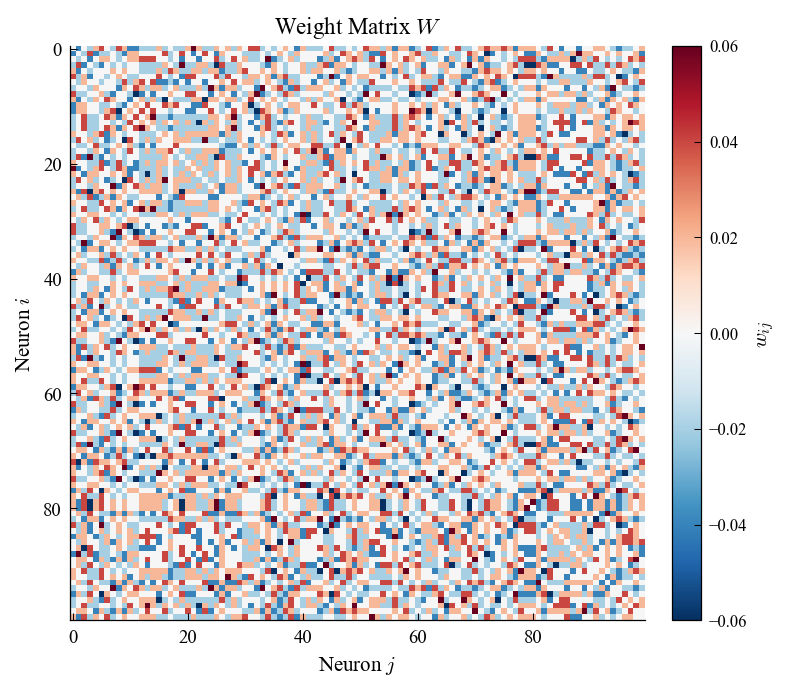

Symmetric            : True
Max diagonal element : 0.00e+00
Weight range         : [-0.0600, 0.0600]


In [6]:
fig = viz.show_weights(figsize=(5.5, 4.5))
plt.show()

print(f"Symmetric            : {np.allclose(net.weights, net.weights.T)}")
print(f"Max diagonal element : {np.max(np.abs(np.diag(net.weights))):.2e}")
print(f"Weight range         : [{net.weights.min():.4f}, {net.weights.max():.4f}]")

<a id="7"></a>
## 7. Overlap Dynamics

The overlap $m^\mu(t)$ is a scalar $\in [-1, 1]$ measuring the alignment between the current state vector $\mathbf{s}(t) \in \{-1,+1\}^N$ and stored pattern vector $\boldsymbol{\xi}^\mu \in \{-1,+1\}^N$:

$$m^\mu(t) = \frac{1}{N} \sum_{i=1}^{N} s_i(t)\, \xi_i^\mu = \frac{1}{N}\, \mathbf{s}(t) \cdot \boldsymbol{\xi}^\mu$$

For $P$ stored patterns, the overlaps form a vector $\mathbf{m}(t) = (m^1(t), \dots, m^P(t))^T \in [-1,1]^P$.

| Value | Interpretation |
|---|---|
| $m^\mu = +1$ | State vector $\mathbf{s}$ is identical to pattern vector $\boldsymbol{\xi}^\mu$ |
| $m^\mu = -1$ | State is the negative $-\boldsymbol{\xi}^\mu$ (also a fixed point) |
| $m^\mu \approx 0$ | State is uncorrelated with pattern $\mu$ |

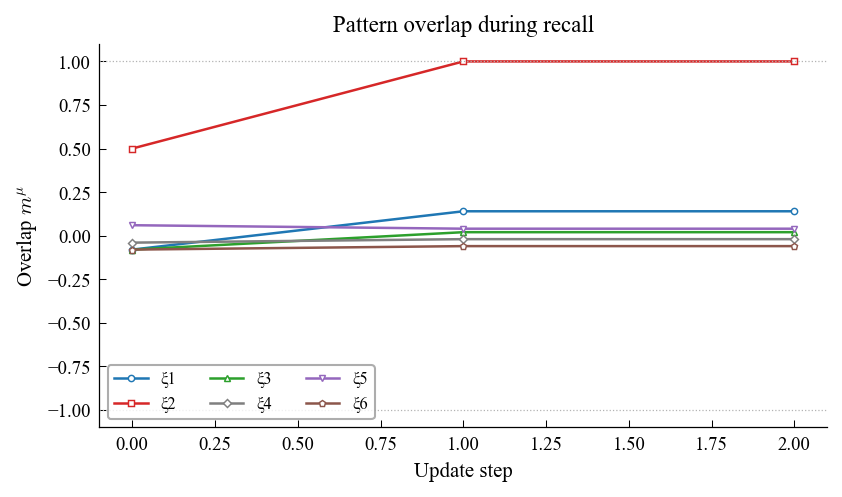

Final overlaps: {'ξ1': '0.140', 'ξ2': '1.000', 'ξ3': '0.020', 'ξ4': '-0.020', 'ξ5': '0.040', 'ξ6': '-0.060'}


In [7]:
noisy_probe = add_noise(patterns[1], noise_level=DEFAULT_NOISE, rng=np.random.default_rng(7))
recalled, info = net.recall(noisy_probe, mode="async", max_steps=MAX_STEPS, record_history=True)

fig = viz.plot_overlap_trajectory(
    info["state_history"],
    pattern_labels=[f"ξ{i+1}" for i in range(P)],
)
plt.show()

final_overlaps = net.overlap_with_patterns(recalled)
print("Final overlaps:", {f"ξ{i+1}": f"{v:.3f}" for i, v in enumerate(final_overlaps)})

<a id="8"></a>
## 8. Synchronous vs Asynchronous Dynamics

### Asynchronous Update
- Pick a neuron index $i$ (scalar $\in \{1,\dots,N\}$)
- Compute its local field $h_i = \sum_j w_{ij} s_j$ (scalar $\in \mathbb{R}$)
- Update: $s_i \leftarrow \operatorname{sgn}(h_i)$ (scalar $\in \{-1,+1\}$)
- Guarantees energy descent: $\Delta E \leq 0$ (scalar)
- Always converges to a fixed-point vector

### Synchronous Update
- Compute the full field vector $\mathbf{h} = W\mathbf{s}$ $\in \mathbb{R}^N$
- Update every component: $\mathbf{s}(t+1) = \operatorname{sgn}(\mathbf{h})$ $\in \{-1,+1\}^N$
- Can produce limit cycles of period 2 (the state vector oscillates between two vectors)
- Faster per step but no monotone energy guarantee

ASYNC: converged=True, steps=2, overlap=1.000
SYNC: converged=True, steps=2, overlap=1.000


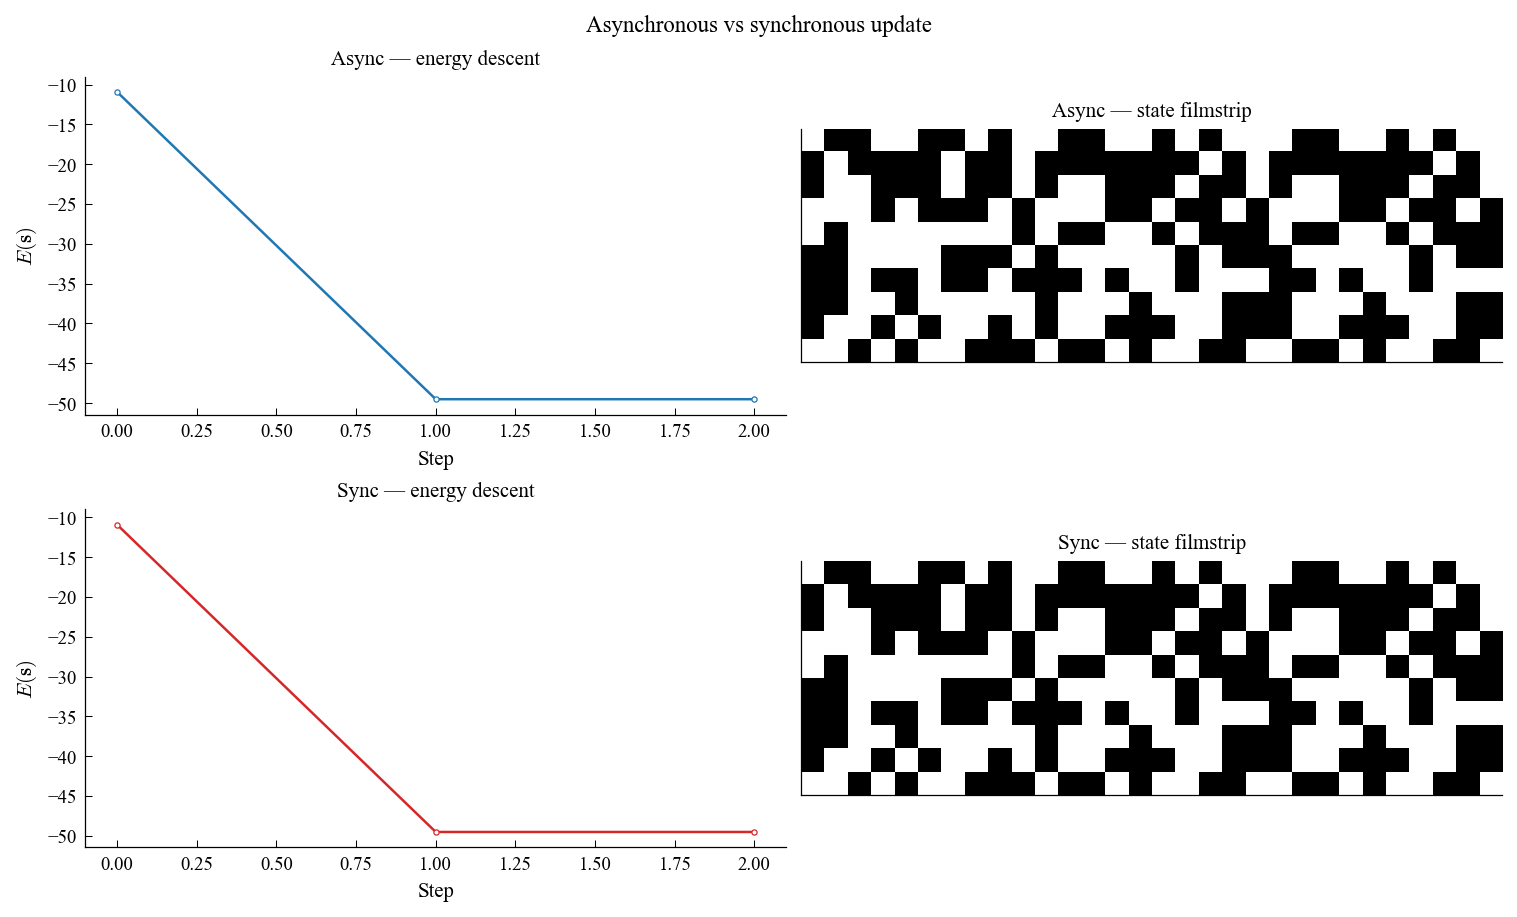

In [8]:
from hopfield.visualization import _PALETTE

probe = add_noise(patterns[0], noise_level=DEFAULT_NOISE, rng=np.random.default_rng(SEED))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for row, mode in enumerate(["async", "sync"]):
    recalled, info = net.recall(probe, mode=mode, max_steps=MAX_STEPS, record_history=True)

    ax_e = axes[row, 0]
    ax_e.plot(info["energy_history"], "-o", color=_PALETTE[row], markersize=2.5,
              markerfacecolor="white", markeredgewidth=0.6, markeredgecolor=_PALETTE[row])
    ax_e.set_title(f"{mode.capitalize()} — energy descent", fontsize=10)
    ax_e.set_xlabel("Step")
    ax_e.set_ylabel(r"$E(\mathbf{s})$")

    n_show  = min(6, len(info["state_history"]))
    indices = np.linspace(0, len(info["state_history"]) - 1, n_show, dtype=int)
    strip   = np.hstack([info["state_history"][i].reshape(GRID_SHAPE) for i in indices])

    ax_s = axes[row, 1]
    ax_s.imshow(strip, cmap="gray_r", interpolation="nearest", vmin=-1, vmax=1)
    ax_s.set_title(f"{mode.capitalize()} — state filmstrip", fontsize=10)
    ax_s.set_xticks([]); ax_s.set_yticks([])

    m = overlap(recalled, patterns[0])
    print(f"{mode.upper()}: converged={info['converged']}, steps={info['steps']}, overlap={m:.3f}")

fig.suptitle("Asynchronous vs synchronous update", fontsize=11)
plt.show()

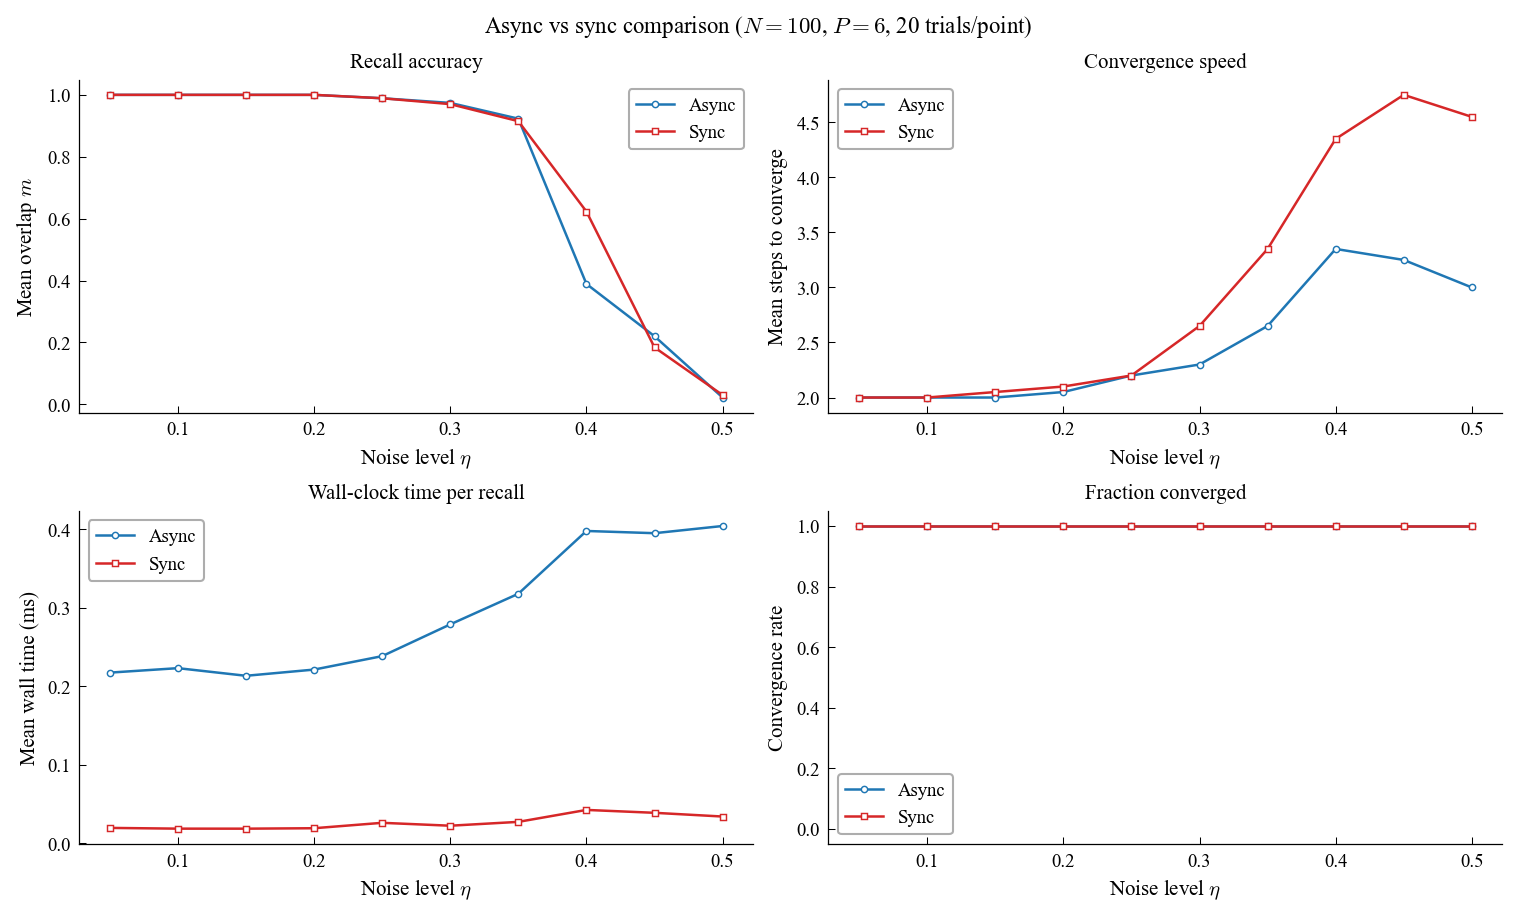

     η |   Async m    Sync m |  Async steps   Sync steps |   Async ms    Sync ms |  Async conv   Sync conv
--------------------------------------------------------------------------------------------------------------
  0.05 |     1.000     1.000 |          2.0          2.0 |       0.22       0.02 |        100%        100%
  0.10 |     1.000     1.000 |          2.0          2.0 |       0.22       0.02 |        100%        100%
  0.15 |     1.000     1.000 |          2.0          2.0 |       0.21       0.02 |        100%        100%
  0.20 |     1.000     1.000 |          2.0          2.1 |       0.22       0.02 |        100%        100%
  0.25 |     0.989     0.989 |          2.2          2.2 |       0.24       0.03 |        100%        100%
  0.30 |     0.974     0.970 |          2.3          2.6 |       0.28       0.02 |        100%        100%
  0.35 |     0.923     0.915 |          2.6          3.4 |       0.32       0.03 |        100%        100%
  0.40 |     0.389     0.623 |   

In [9]:
import time

noise_sweep = np.arange(0.05, 0.55, 0.05)
n_trials_mode = 20
modes = ["async", "sync"]

stats = {mode: {"overlap": [], "steps": [], "time_ms": [], "converged": []} for mode in modes}

for eta in noise_sweep:
    for mode in modes:
        overlaps, steps, times, convs = [], [], [], []
        for trial in range(n_trials_mode):
            rng_t = np.random.default_rng(trial * 300 + int(eta * 1000))
            mu = trial % P
            probe_t = add_noise(patterns[mu], noise_level=eta, rng=rng_t)

            t0 = time.perf_counter()
            rec, info = net.recall(probe_t, mode=mode, max_steps=MAX_STEPS)
            elapsed = (time.perf_counter() - t0) * 1000

            overlaps.append(overlap(rec, patterns[mu]))
            steps.append(info["steps"])
            times.append(elapsed)
            convs.append(info["converged"])

        stats[mode]["overlap"].append(np.mean(overlaps))
        stats[mode]["steps"].append(np.mean(steps))
        stats[mode]["time_ms"].append(np.mean(times))
        stats[mode]["converged"].append(np.mean(convs))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
_mode_styles = {"async": dict(color=_PALETTE[0], marker="o", label="Async"),
                "sync":  dict(color=_PALETTE[1], marker="s", label="Sync")}

panels = [
    (axes[0, 0], "overlap",    r"Mean overlap $m$",          "Recall accuracy"),
    (axes[0, 1], "steps",      "Mean steps to converge",     "Convergence speed"),
    (axes[1, 0], "time_ms",    "Mean wall time (ms)",        "Wall-clock time per recall"),
    (axes[1, 1], "converged",  "Convergence rate",           "Fraction converged"),
]

for ax, key, ylabel, title in panels:
    for mode in modes:
        s = _mode_styles[mode]
        ax.plot(noise_sweep, stats[mode][key], linestyle="-", marker=s["marker"],
                color=s["color"], markersize=3, markerfacecolor="white",
                markeredgewidth=0.7, markeredgecolor=s["color"], label=s["label"])
    ax.set_xlabel(r"Noise level $\eta$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=True)
    if key == "converged":
        ax.set_ylim(-0.05, 1.05)

fig.suptitle(f"Async vs sync comparison ($N={N}$, $P={P}$, {n_trials_mode} trials/point)", fontsize=11)
plt.show()

print(f"{'η':>6} | {'Async m':>9} {'Sync m':>9} | {'Async steps':>12} {'Sync steps':>12} | {'Async ms':>10} {'Sync ms':>10} | {'Async conv':>11} {'Sync conv':>11}")
print("-" * 110)
for i, eta in enumerate(noise_sweep):
    print(f"{eta:6.2f} | "
          f"{stats['async']['overlap'][i]:9.3f} {stats['sync']['overlap'][i]:9.3f} | "
          f"{stats['async']['steps'][i]:12.1f} {stats['sync']['steps'][i]:12.1f} | "
          f"{stats['async']['time_ms'][i]:10.2f} {stats['sync']['time_ms'][i]:10.2f} | "
          f"{stats['async']['converged'][i]:11.0%} {stats['sync']['converged'][i]:11.0%}")

<a id="9"></a>
## 9. Storage Capacity Experiment

### Theoretical Bounds

The load ratio $\alpha$ is a scalar defined as:

$$\alpha = \frac{P}{N} \quad \in \mathbb{R}^+$$

where $P$ (scalar) is the number of stored pattern vectors and $N$ (scalar) is the network size.

| Threshold | Value | Meaning |
|---|---|---|
| $\alpha_c$ (Hebbian) | $\approx 0.138$ | Above this, overlap scalars $m^\mu$ collapse to $\approx 0$ |
| $P_{\max}$ (exact recall) | $\approx N / (2 \ln N)$ | Max patterns for perfect retrieval (all $m^\mu = 1$) |

We test the fixed-point criterion: initialise the network at the exact stored pattern (0% noise) and check whether it remains stable after one full recall pass. This matches the theoretical definition of $P_c$ — the load at which stored patterns stop being fixed points of the dynamics.

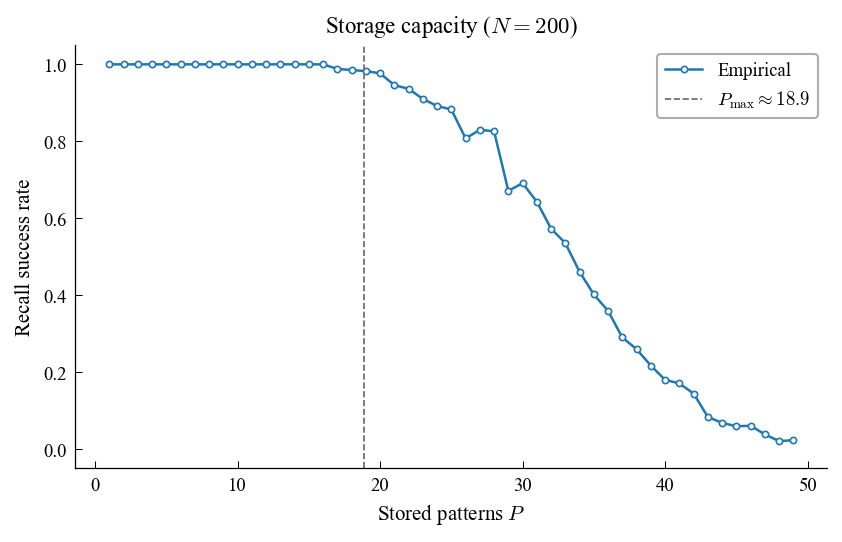

⚠ Recall drops below 90% at P = 24 (α = 0.120)


In [ ]:
success_rates = []

for P_test in P_RANGE_CAP:
    successes = 0
    total = 0
    for trial in range(N_TRIALS_CAP):
        rng = np.random.default_rng(trial * 100 + P_test)
        pats = generate_random_patterns(P_test, N_CAP, seed=trial * 100 + P_test)

        net_cap = HopfieldNetwork(N_CAP)
        net_cap.train(pats)

        for mu in range(P_test):
            probe = add_noise(pats[mu], noise_level=NOISE_CAP, rng=rng) if NOISE_CAP > 0 else pats[mu].copy()
            recalled, _ = net_cap.recall(probe, mode="async", max_steps=MAX_STEPS)
            if overlap(recalled, pats[mu]) > 0.95:
                successes += 1
            total += 1

    success_rates.append(successes / total)

viz_cap = HopfieldVisualizer(HopfieldNetwork(N_CAP))
fig = viz_cap.plot_capacity_curve(P_RANGE_CAP, success_rates, N_CAP)
plt.show()

for i, sr in enumerate(success_rates):
    if sr < 0.9:
        print(f"Recall drops below 90% at P = {P_RANGE_CAP[i]} (α = {P_RANGE_CAP[i]/N_CAP:.3f})")
        break

<a id="10"></a>
## 10. Hebbian vs Storkey Learning

The Storkey rule (1997) updates each scalar entry $w_{ij}$ of the weight matrix incrementally for each new pattern vector $\boldsymbol{\xi}^\nu$:

$$w_{ij}^{\nu} = w_{ij}^{\nu-1} + \frac{1}{N}\left(\xi_i^\nu \xi_j^\nu - \xi_i^\nu h_{ji}^\nu - h_{ij}^\nu \xi_j^\nu\right)$$

where $h_{ij}^\nu = \sum_{k \neq i,j} w_{ik}^{\nu-1} \xi_k^\nu$ is the local field (scalar $\in \mathbb{R}$) at neuron $i$ due to pattern $\nu$, excluding the direct contribution from neuron $j$.

| Rule | Capacity $P_c$ | $P_c$ for $N=200$ | Weight computation |
|---|---|---|---|
| Hebbian | $\approx 0.138\, N$ | $\approx 28$ | Single outer-product sum of pattern vectors |
| Storkey | $\approx N \sqrt{2 \ln N}$ | $\approx 61$ | Incremental: accounts for cross-talk via local field scalars |

The experiment below starts from the exact stored patterns (0% noise) to test fixed-point stability, matching the theoretical criterion.

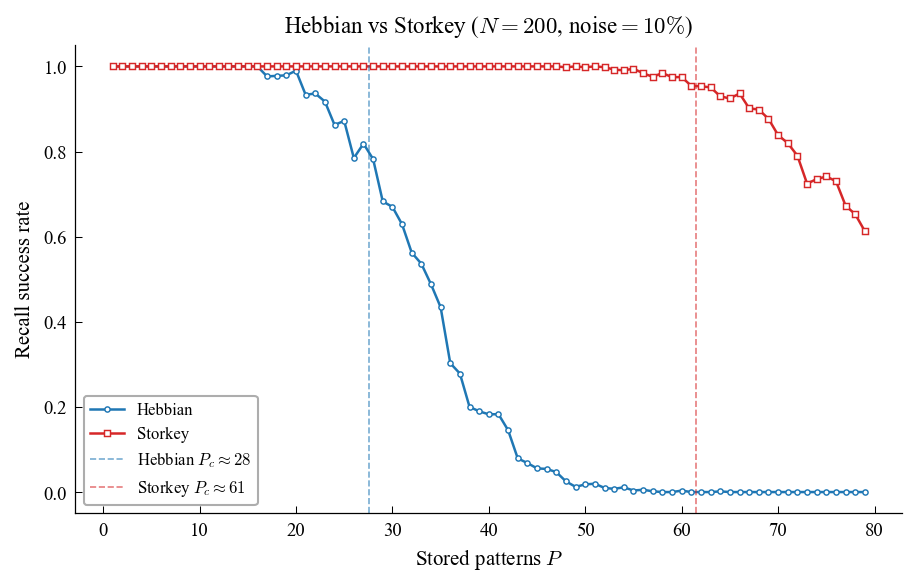

In [11]:
results = {"Hebbian": [], "Storkey": []}

for P_test in P_RANGE_COMP:
    heb_success, stork_success = 0, 0
    total = 0
    for trial in range(N_TRIALS_COMP):
        seed = trial * 200 + P_test
        pats = generate_random_patterns(P_test, N_COMP, seed=seed)
        rng = np.random.default_rng(seed)

        net_heb = HopfieldNetwork(N_COMP)
        net_heb.train(pats)

        net_stk = HopfieldNetwork(N_COMP)
        net_stk.train_storkey(pats)

        for mu in range(P_test):
            probe = add_noise(pats[mu], noise_level=NOISE_COMP, rng=rng) if NOISE_COMP > 0 else pats[mu].copy()
            rec_h, _ = net_heb.recall(probe.copy(), mode="async", max_steps=MAX_STEPS)
            rec_s, _ = net_stk.recall(probe.copy(), mode="async", max_steps=MAX_STEPS)
            if overlap(rec_h, pats[mu]) > 0.95:
                heb_success += 1
            if overlap(rec_s, pats[mu]) > 0.95:
                stork_success += 1
            total += 1

    results["Hebbian"].append(heb_success / total)
    results["Storkey"].append(stork_success / total)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(P_RANGE_COMP, results["Hebbian"], "-o", color=_PALETTE[0], markersize=2.5,
        markerfacecolor="white", markeredgewidth=0.7, markeredgecolor=_PALETTE[0], label="Hebbian")
ax.plot(P_RANGE_COMP, results["Storkey"], "-s", color=_PALETTE[1], markersize=2.5,
        markerfacecolor="white", markeredgewidth=0.7, markeredgecolor=_PALETTE[1], label="Storkey")

p_heb = 0.138 * N_COMP
p_stk = N_COMP / np.sqrt(2 * np.log(N_COMP))
ax.axvline(p_heb, color=_PALETTE[0], ls="--", lw=0.8, alpha=0.6, label=rf"Hebbian $P_c \approx {p_heb:.0f}$")
ax.axvline(p_stk, color=_PALETTE[1], ls="--", lw=0.8, alpha=0.6, label=rf"Storkey $P_c \approx {p_stk:.0f}$")

ax.set_xlabel(r"Stored patterns $P$")
ax.set_ylabel("Recall success rate")
ax.set_title(f"Hebbian vs Storkey ($N={N_COMP}$, noise$={NOISE_COMP*100:.0f}\%$)", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=True, fontsize=8)
plt.show()

<a id="11"></a>
## 11. Basin of Attraction Analysis

Each stored pattern vector $\boldsymbol{\xi}^\mu \in \{-1,+1\}^N$ has a basin of attraction — the set of all initial state vectors $\mathbf{s}(0)$ that converge to $\boldsymbol{\xi}^\mu$ under the dynamics.

We estimate the basin fraction (scalar $\in [0,1]$) for each pattern by:
1. Sampling random probe vectors $\mathbf{s}(0) \in \{-1,+1\}^N$
2. Running recall to get the final state vector $\mathbf{s}^*$
3. Computing the overlap scalar $m^\mu = \frac{1}{N}\, \mathbf{s}^* \cdot \boldsymbol{\xi}^\mu$ to classify which attractor was reached

- Larger basin fraction → more robust recall
- Basin fractions shrink as the load ratio $\alpha = P/N$ (scalar) increases
- States converging to non-stored vectors are counted as "spurious"

Basin of attraction sizes (fraction of state space):
  Pattern 1: 8.9%
  Pattern 2: 9.4%
  Pattern 3: 14.2%
  Pattern 4: 11.7%
  Pattern 5: 11.2%
  Pattern 6: 8.8%
  Spurious: 35.8%


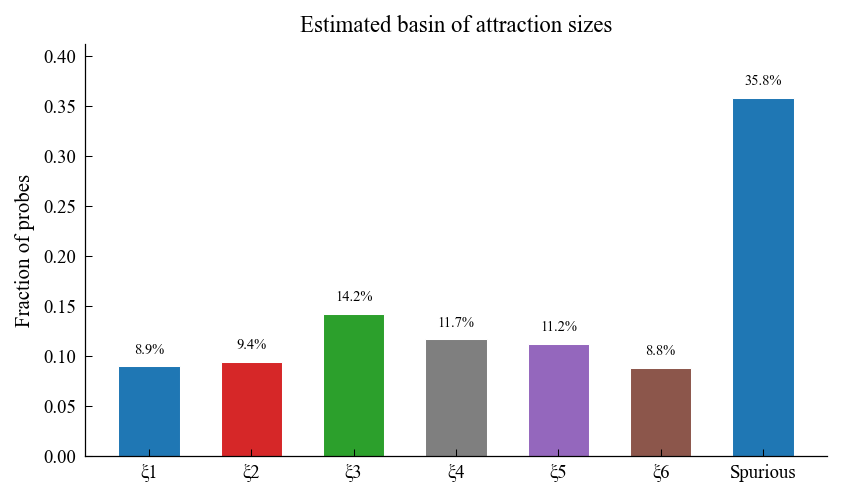

In [12]:
analyzer = EnergyAnalyzer(net)
basin_sizes = analyzer.estimate_basin_sizes(n_probes=N_PROBES_BASIN)

print("Basin of attraction sizes (fraction of state space):")
for k, v in basin_sizes.items():
    label = f"Pattern {k+1}" if isinstance(k, int) else k.title()
    print(f"  {label}: {v:.1%}")

fig = viz.plot_basin_sizes(
    basin_sizes,
    pattern_labels=[f"ξ{i+1}" for i in range(P)],
)
plt.show()

<a id="12"></a>
## 12. Spurious States

Not all fixed points of a Hopfield network correspond to stored patterns. Spurious states are additional attractors, including:

| Spurious type | Description | Type |
|---|---|---|
| Negatives $-\boldsymbol{\xi}^\mu$ | Bit-flipped copy of a stored pattern | vector $\in \{-1,+1\}^N$ |
| Mixture states $\mathbf{s}_{\text{mix}}$ | $\operatorname{sgn}\!\bigl(\pm\boldsymbol{\xi}^1 \pm \boldsymbol{\xi}^2 \pm \boldsymbol{\xi}^3\bigr)$, odd combinations of an odd number of patterns | vector $\in \{-1,+1\}^N$ |
| Spin-glass states | Unstructured minima with $m^\mu \approx 0\;\forall\,\mu$ | vector $\in \{-1,+1\}^N$ |

Key variables:
- $\operatorname{sgn}(\cdot)$: element-wise sign function, maps each component to $\pm 1$ (vector → vector)
- $m^\mu$: overlap with pattern $\mu$ (scalar, $\in [-1,1]$)
- The number of spurious states grows rapidly with $N$ (scalar, network size) and $P$ (scalar, number of patterns)

Found 156 unique spurious attractor(s)



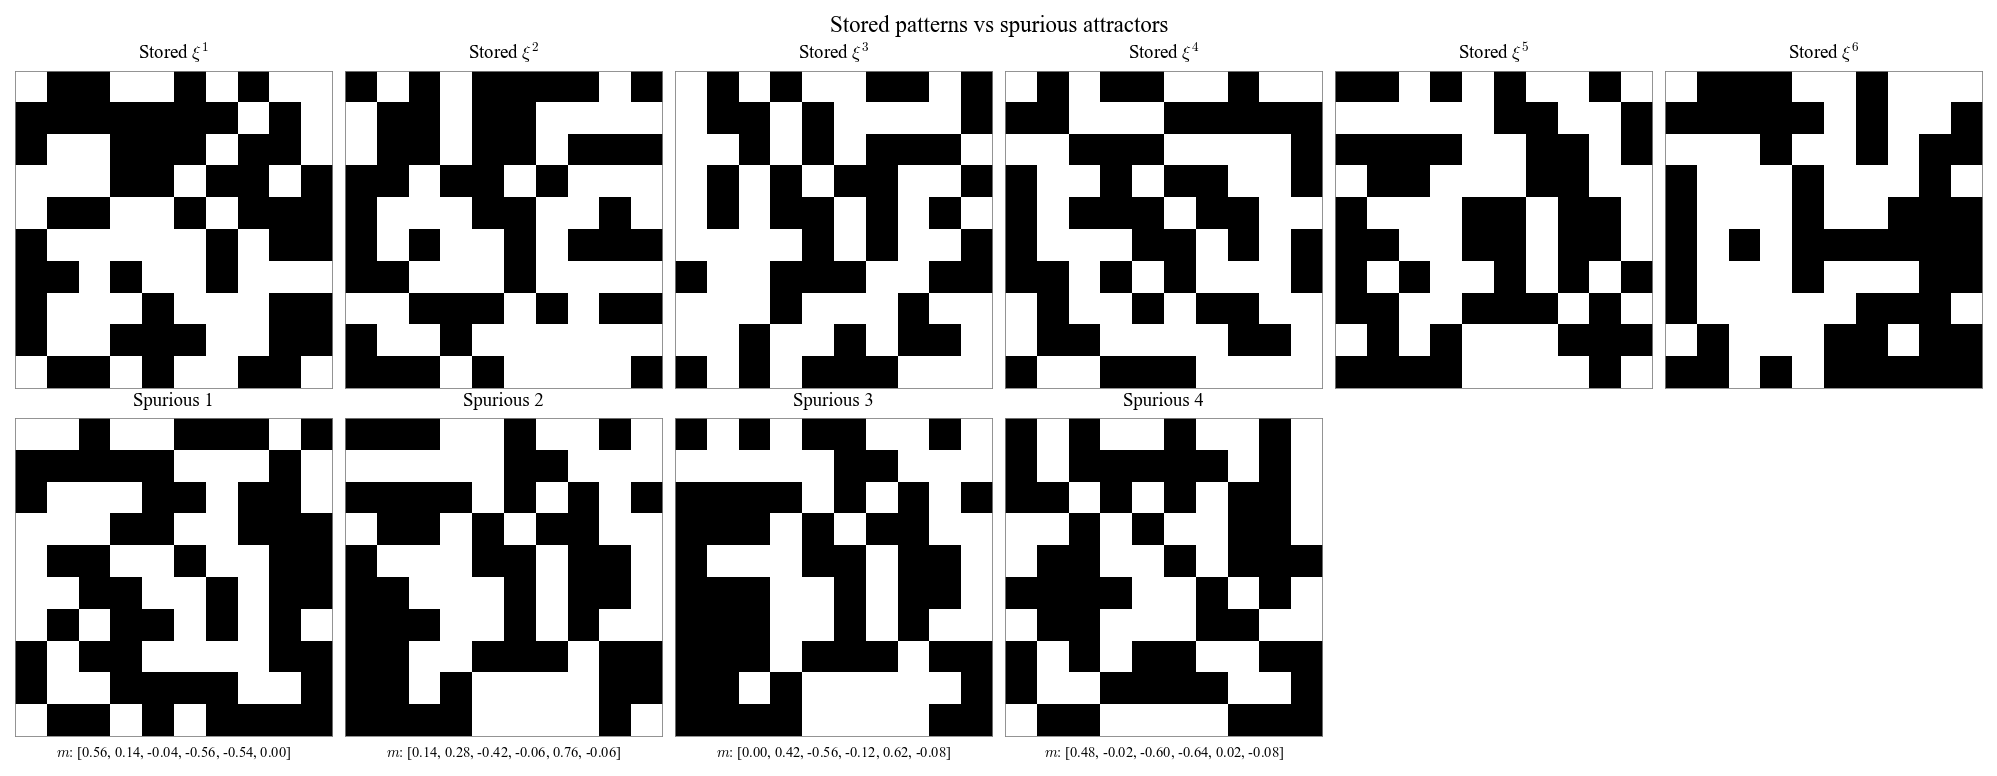

In [13]:
spurious = analyzer.find_spurious_states(n_probes=N_PROBES_SPURIOUS)
print(f"Found {len(spurious)} unique spurious attractor(s)\n")

if spurious:
    n_show = min(4, len(spurious))
    n_cols = max(P, n_show)
    fig, axes = plt.subplots(2, n_cols, figsize=(2.2 * n_cols, 5))

    for i in range(n_cols):
        if i < P:
            axes[0, i].imshow(patterns[i].reshape(GRID_SHAPE), cmap="gray_r", vmin=-1, vmax=1, interpolation="nearest")
            axes[0, i].set_title(rf"Stored $\xi^{{{i+1}}}$", fontsize=9)
        else:
            axes[0, i].axis("off")
        axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
        for spine in axes[0, i].spines.values():
            spine.set_visible(True); spine.set_linewidth(0.4); spine.set_color("0.5")

    for i in range(n_cols):
        if i < n_show:
            axes[1, i].imshow(spurious[i].reshape(GRID_SHAPE), cmap="gray_r", vmin=-1, vmax=1, interpolation="nearest")
            ov = net.overlap_with_patterns(spurious[i])
            ov_str = ", ".join([f"{v:.2f}" for v in ov])
            axes[1, i].set_title(f"Spurious {i+1}", fontsize=9)
            axes[1, i].set_xlabel(f"$m$: [{ov_str}]", fontsize=7)
        else:
            axes[1, i].axis("off")
        axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
        for spine in axes[1, i].spines.values():
            spine.set_visible(True); spine.set_linewidth(0.4); spine.set_color("0.5")

    fig.suptitle("Stored patterns vs spurious attractors", fontsize=11)
    plt.show()
else:
    print("No spurious attractors found in this sampling.")

<a id="13"></a>
## 13. Letter Pattern Recall

A practical example: store 5×5 binary letter images and recall them from noisy probes.

| Variable | Description | Type |
|---|---|---|
| $\boldsymbol{\xi}^\mu$ | Flattened letter image | vector $\in \{-1,+1\}^{25}$ |
| $N$ | Number of pixels ($5 \times 5 = 25$) | scalar, $\mathbb{Z}^+$ |
| $P$ | Number of stored letters | scalar, $\mathbb{Z}^+$ |
| $W$ | Weight matrix for letter network | matrix $\in \mathbb{R}^{25 \times 25}$ |
| $\tilde{\boldsymbol{\xi}}$ | Noisy probe (corrupted letter) | vector $\in \{-1,+1\}^{25}$ |
| $\mathbf{s}^*$ | Recalled (converged) state | vector $\in \{-1,+1\}^{25}$ |

Each pattern is reshaped to a $5 \times 5$ grid for display.

HopfieldNetwork(n_neurons=25, stored_patterns=4, capacity~3.9)
Storing letters: ['H', 'A', 'X', 'T']


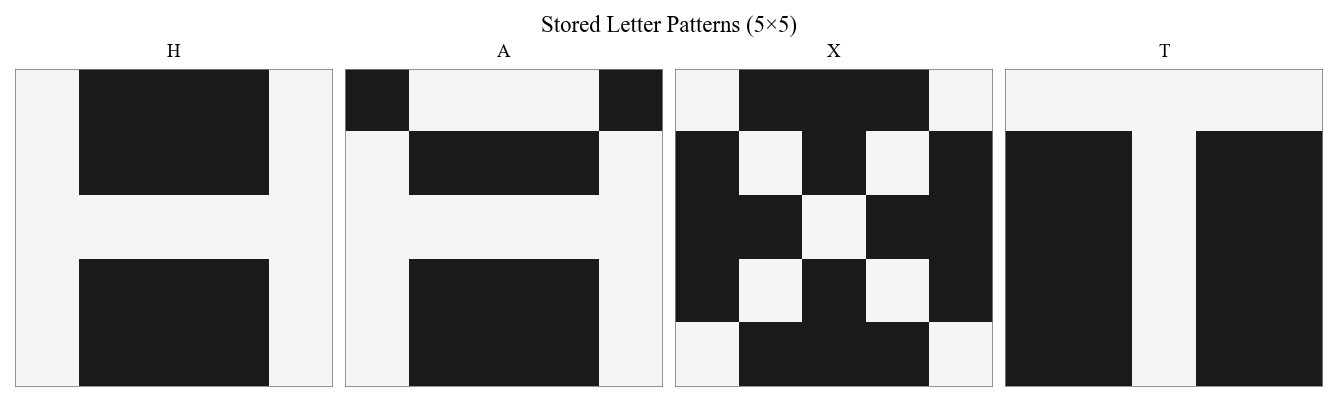

In [14]:
letters = make_letter_patterns()
letter_patterns = np.array([letters[l] for l in LETTER_NAMES])
n_letter_pixels = letter_patterns.shape[1]
letter_side = int(np.sqrt(n_letter_pixels))
letter_grid = (letter_side, letter_side)

net_letters = HopfieldNetwork(n_neurons=n_letter_pixels)
net_letters.train(letter_patterns)
viz_letters = HopfieldVisualizer(net_letters, grid_shape=letter_grid)

print(net_letters)
print(f"Storing letters: {LETTER_NAMES}")

fig = viz_letters.show_patterns(
    letter_patterns,
    titles=LETTER_NAMES,
    suptitle=f"Stored Letter Patterns ({letter_side}×{letter_side})",
)
plt.show()

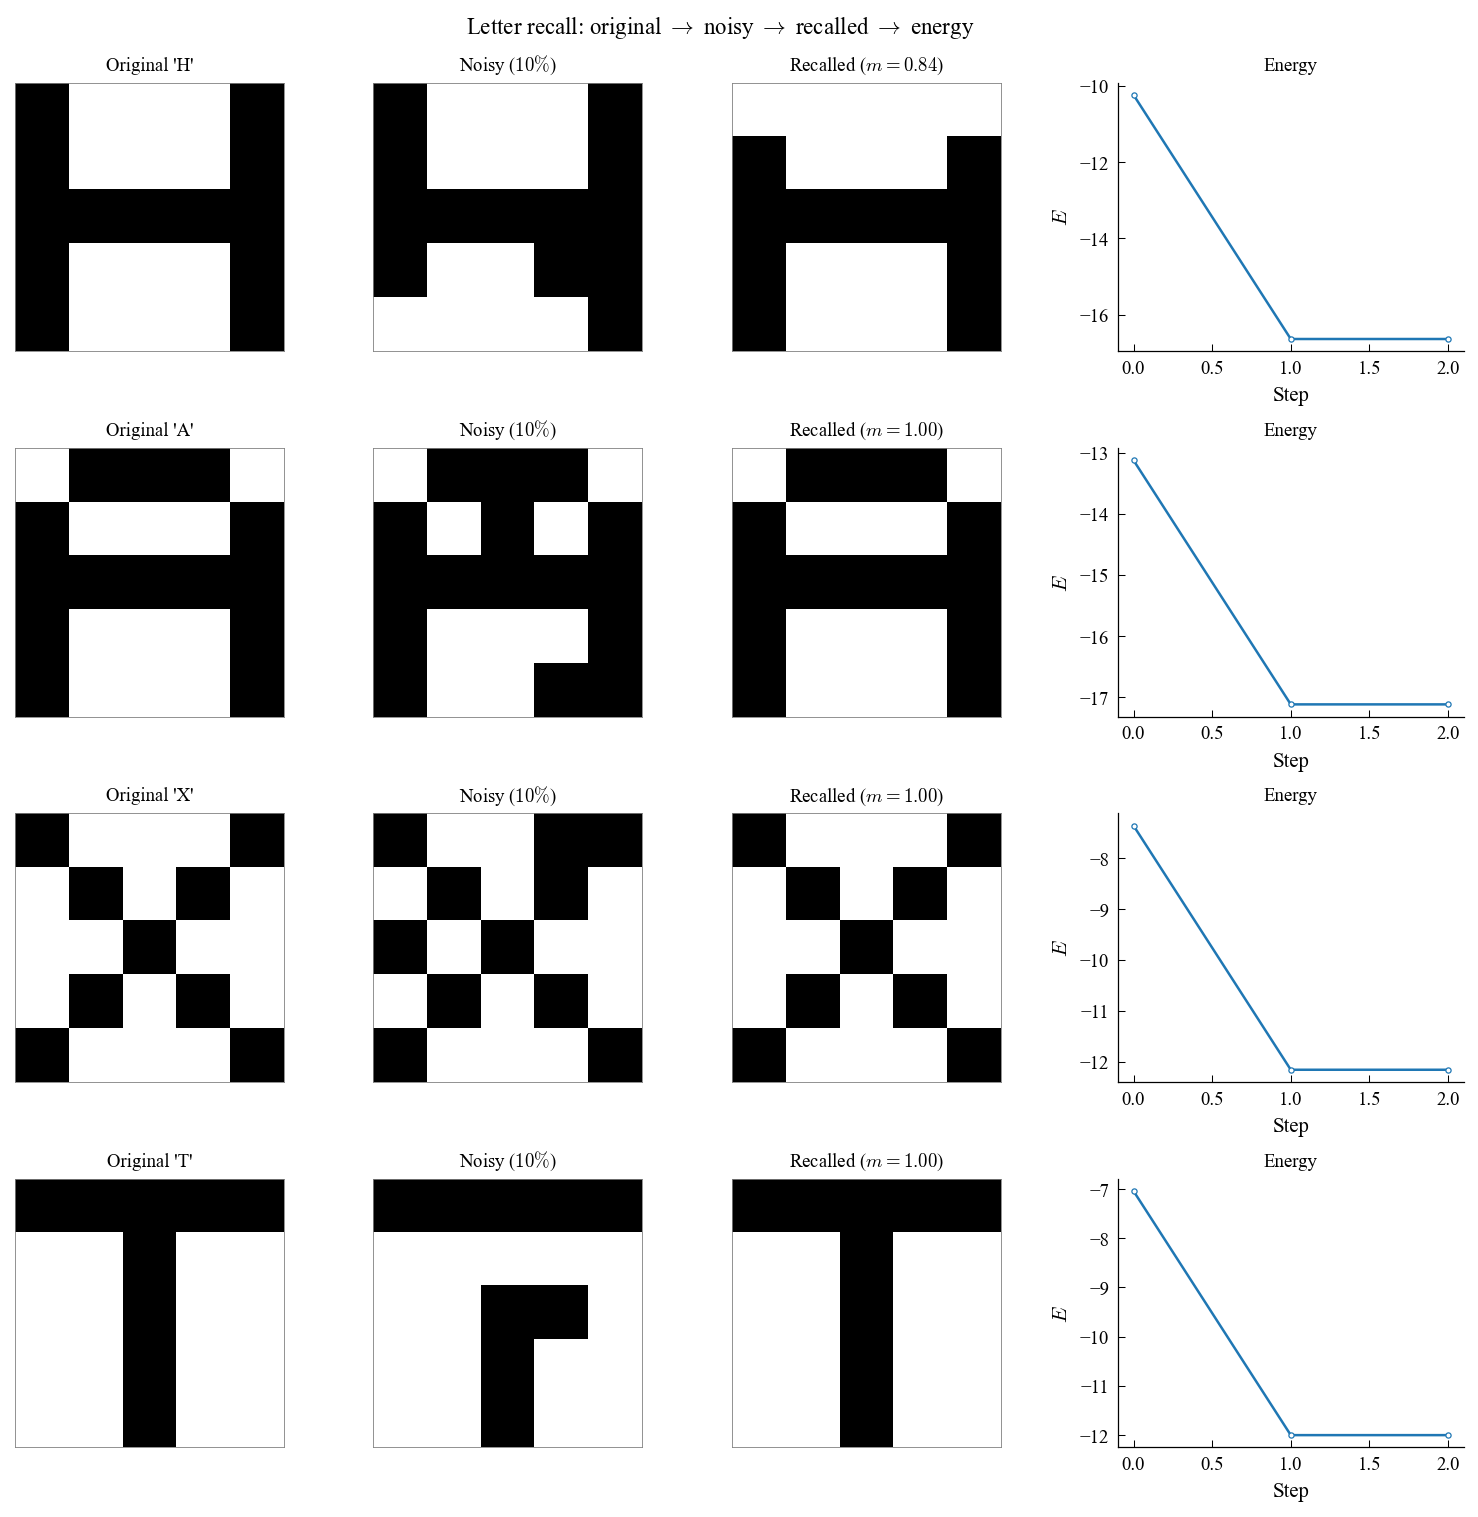

In [15]:
fig, axes = plt.subplots(len(LETTER_NAMES), 4, figsize=(10, 2.5 * len(LETTER_NAMES)))

for row, (name, pat) in enumerate(zip(LETTER_NAMES, letter_patterns)):
    rng_l = np.random.default_rng(row + 100)
    noisy = add_noise(pat, noise_level=LETTER_NOISE, rng=rng_l)
    recalled, info = net_letters.recall(noisy, mode="async", max_steps=MAX_STEPS, record_history=True)

    axes[row, 0].imshow(pat.reshape(letter_grid), cmap="gray_r", vmin=-1, vmax=1, interpolation="nearest")
    axes[row, 0].set_title(f"Original '{name}'", fontsize=9)

    axes[row, 1].imshow(noisy.reshape(letter_grid), cmap="gray_r", vmin=-1, vmax=1, interpolation="nearest")
    axes[row, 1].set_title(rf"Noisy (${LETTER_NOISE*100:.0f}\%$)", fontsize=9)

    axes[row, 2].imshow(recalled.reshape(letter_grid), cmap="gray_r", vmin=-1, vmax=1, interpolation="nearest")
    m = overlap(recalled, pat)
    axes[row, 2].set_title(f"Recalled ($m={m:.2f}$)", fontsize=9)

    axes[row, 3].plot(info["energy_history"], "-o", color=_PALETTE[0], markersize=2.5,
                      markerfacecolor="white", markeredgewidth=0.6, markeredgecolor=_PALETTE[0])
    axes[row, 3].set_title("Energy", fontsize=9)
    axes[row, 3].set_xlabel("Step")
    axes[row, 3].set_ylabel(r"$E$")

    for col in range(3):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        for spine in axes[row, col].spines.values():
            spine.set_visible(True); spine.set_linewidth(0.4); spine.set_color("0.5")

fig.suptitle(r"Letter recall: original $\rightarrow$ noisy $\rightarrow$ recalled $\rightarrow$ energy",
             fontsize=11)
plt.show()

<a id="14"></a>
## 14. Convergence Analysis

We measure how quickly the network reaches a fixed point under different conditions.

| Variable | Description | Type |
|---|---|---|
| $T$ | Number of update steps until convergence | scalar, $\mathbb{Z}_{\ge 0}$ |
| $f$ | Noise fraction applied to the probe | scalar, $\in [0, 0.5]$ |
| $\alpha = P/N$ | Load ratio | scalar, $\in \mathbb{R}^+$ |
| $\mathbf{s}(t)$ | Network state at step $t$ | vector $\in \{-1,+1\}^N$ |
| $\mathbf{s}^*$ | Final converged state | vector $\in \{-1,+1\}^N$ |

Experiments:
1. Convergence vs noise $f$: Fix $P$, vary $f$ — higher noise generally means more steps $T$
2. Convergence vs load $\alpha$: Fix $f$, vary $P/N$ — overloading the network causes slower or failed convergence

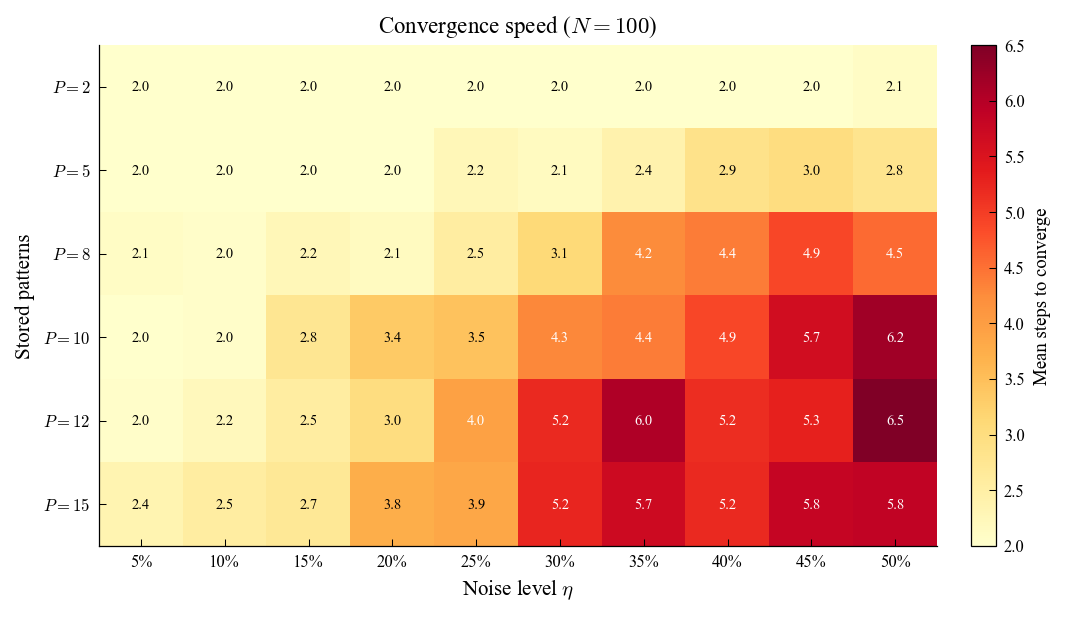

In [16]:
conv_matrix = np.zeros((len(P_LIST_CONV), len(NOISE_RANGE_CONV)))

for pi, P_test in enumerate(P_LIST_CONV):
    pats     = generate_random_patterns(P_test, N_CONV, seed=pi * 50)
    net_conv = HopfieldNetwork(N_CONV)
    net_conv.train(pats)

    for ni, eta in enumerate(NOISE_RANGE_CONV):
        steps_list = []
        for trial in range(N_TRIALS_CONV):
            rng = np.random.default_rng(pi * 1000 + ni * 100 + trial)
            mu = trial % P_test
            noisy = add_noise(pats[mu], noise_level=eta, rng=rng)
            _, info = net_conv.recall(noisy, mode="async", max_steps=MAX_STEPS + 50)
            steps_list.append(info["steps"])
        conv_matrix[pi, ni] = np.mean(steps_list)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(conv_matrix, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(NOISE_RANGE_CONV)))
ax.set_xticklabels([f"{x:.0%}" for x in NOISE_RANGE_CONV], fontsize=8)
ax.set_yticks(range(len(P_LIST_CONV)))
ax.set_yticklabels([f"$P={p}$" for p in P_LIST_CONV], fontsize=8)

for i in range(conv_matrix.shape[0]):
    for j in range(conv_matrix.shape[1]):
        val = conv_matrix[i, j]
        color = "white" if val > conv_matrix.max() * 0.6 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean steps to converge", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax.set_xlabel(r"Noise level $\eta$")
ax.set_ylabel("Stored patterns")
ax.set_title(f"Convergence speed ($N={N_CONV}$)", fontsize=11)
plt.show()


Key results demonstrated:
- Hebbian and Storkey learning rules
- Energy monotonically decreases under asynchronous updates
- Recall degrades near the critical capacity $\alpha_c \approx 0.138$
- Spurious states (negatives, mixtures) coexist with stored attractors
- Basin sizes shrink as the network approaches capacity